# Information Theory (Dayan & Abbott, Ch. 4)

Working through the chapter's three sections with derivations, not just definitions:

1. Entropy and mutual information — where the $-\sum p\log p$ formula actually comes from, and how mutual information falls out of it algebraically
2. Information/entropy maximization — why a max-entropy distribution is uniform (discrete, fixed support) or Gaussian (continuous, fixed variance), derived via Lagrange multipliers, and why this matters for neural coding (Laughlin's efficient-coding result)
3. Entropy/information for spike trains — the direct method (Strong et al. 1998), worked on a simulated spike train
4. A bonus tie-back to this repo: deriving the BCI information-transfer-rate (ITR, bits/min) formula from the same mutual-information machinery, since it's the shared metric named in [03-bci-signal-processing's README](../../../03-bci-signal-processing/README.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)

## 1. Entropy — where does $-\sum p \log p$ come from?

It's tempting to just accept $H(X) = -\sum_i p_i \log_2 p_i$ as a definition. But Shannon derived it from requiring a small set of sensible properties for any "amount of uncertainty" measure $H$. Here's the piece of that derivation that's short enough to do honestly by hand: **why the uniform-distribution case must be a logarithm.**

Let $A(n)$ = the uncertainty of a single choice among $n$ **equally likely** outcomes (e.g. $A(2)$ = uncertainty of one fair coin flip). Two requirements:

1. **Monotonicity**: more equally-likely outcomes means more uncertainty, so $A(n)$ is increasing in $n$.
2. **Additivity over independent choices**: choosing among $n$ options and, independently, among $m$ options is the same as one choice among $nm$ combined options, so
$$A(nm) = A(n) + A(m).$$

Requirement 2 is exactly Cauchy's multiplicative-to-additive functional equation. Its only monotonic solutions are $A(n) = c\log(n)$ for some constant $c$ (fix the base of the log by choosing units — base 2 gives "bits"). So the logarithm isn't an arbitrary choice of scale, it's *forced* by wanting uncertainty to add up correctly over independent choices.

Extending this (the fuller argument, via a **grouping axiom** — splitting one choice into two successive choices should give a weighted average of the sub-choices' entropies — is in the chapter appendix, not reproduced here) to *unequal* probabilities gives the general form
$$H(X) = -\sum_i p_i \log_2 p_i \quad \text{(bits)}.$$

Quick numerical sanity check of the additivity property that drove the derivation:

In [2]:
def entropy_bits(p):
    """H(X) for a distribution p (array of probabilities), in bits.
    0*log2(0) is treated as 0 by convention (the limit)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


n, m = 4, 3
A_n = entropy_bits(np.full(n, 1 / n))
A_m = entropy_bits(np.full(m, 1 / m))
A_nm = entropy_bits(np.full(n * m, 1 / (n * m)))

print(f"A({n})            = {A_n:.4f} bits  (= log2({n}) = {np.log2(n):.4f})")
print(f"A({m})            = {A_m:.4f} bits  (= log2({m}) = {np.log2(m):.4f})")
print(f"A({n}*{m})          = {A_nm:.4f} bits")
print(f"A({n}) + A({m})     = {A_n + A_m:.4f} bits  <- matches A({n}*{m}), confirming additivity")

A(4)            = 2.0000 bits  (= log2(4) = 2.0000)
A(3)            = 1.5850 bits  (= log2(3) = 1.5850)
A(4*3)          = 3.5850 bits
A(4) + A(3)     = 3.5850 bits  <- matches A(4*3), confirming additivity


### The Bernoulli case — a single spike bin

The simplest neuroscience-relevant case: a single short time bin either contains a spike (probability $p$) or not (probability $1-p$). This is the building block for the spike-train entropy in Section 3.
$$H_b(p) = -p\log_2 p - (1-p)\log_2(1-p)$$
Maximized at $p=0.5$ (maximum uncertainty about whether a spike occurred), zero at $p=0$ or $p=1$ (no uncertainty — you already know the answer).

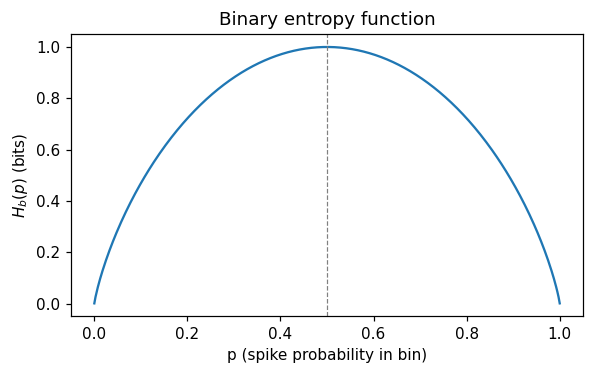

H_b(0.5) = 1.0000 bit (exactly 1 bit, as expected)


In [3]:
p_grid = np.linspace(1e-4, 1 - 1e-4, 400)
Hb = -p_grid * np.log2(p_grid) - (1 - p_grid) * np.log2(1 - p_grid)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(p_grid, Hb)
ax.axvline(0.5, color="grey", ls="--", lw=0.8)
ax.set_xlabel("p (spike probability in bin)")
ax.set_ylabel("$H_b(p)$ (bits)")
ax.set_title("Binary entropy function")
plt.tight_layout()
plt.savefig("figures/01_binary_entropy.png")
plt.show()

print(f"H_b(0.5) = {-0.5*np.log2(0.5) - 0.5*np.log2(0.5):.4f} bit (exactly 1 bit, as expected)")

### Joint entropy, conditional entropy, mutual information

For two variables $X$ (e.g. stimulus) and $Y$ (e.g. response):

$$H(X,Y) = -\sum_{x,y} p(x,y)\log_2 p(x,y) \qquad \text{(joint entropy)}$$
$$H(Y\mid X) = -\sum_{x,y} p(x,y)\log_2 p(y\mid x) \qquad \text{(conditional / "noise" entropy)}$$

**Mutual information** $I(X;Y)$ is defined as how much knowing $Y$ reduces uncertainty about $X$: $I(X;Y) = H(X) - H(X\mid Y)$. Deriving the more commonly used forms from the definitions above is pure algebra — worth doing once by hand so it's not just a fact to memorize:

$$H(X\mid Y) = \sum_{x,y} p(x,y)\log_2\frac{p(y)}{p(x,y)} = \sum_{x,y}p(x,y)\big[\log_2 p(y) - \log_2 p(x,y)\big] = H(X,Y) - H(Y)$$

so

$$I(X;Y) = H(X) - H(X\mid Y) = H(X) + H(Y) - H(X,Y).$$

This form is symmetric in $X$ and $Y$ — which is not obvious from the "how much does $Y$ tell you about $X$" definition, but falls straight out of the algebra. It also equals $H(Y) - H(Y\mid X)$: for a neuron, this is "total response entropy minus the entropy left over once you already know the stimulus" — i.e. the part of the response variability that's actually *about* the stimulus rather than noise. This is exactly the decomposition the direct method uses in Section 3.

**Worked example: the binary symmetric channel (BSC).** Input $X\in\{0,1\}$ with $P(X=1)=p$; output $Y$ is $X$ flipped with probability $\varepsilon$ (a crude but standard model of a noisy channel — or a noisy binary neural response). Compute $I(X;Y)$ symbolically as a function of $p$ and $\varepsilon$.

In [4]:
p_sym, eps_sym = sp.symbols("p epsilon", positive=True)


def Hb_sym(x):
    return -x * sp.log(x, 2) - (1 - x) * sp.log(1 - x, 2)


# P(Y=1) marginal, and H(Y|X) (same for X=0 or X=1 since the flip prob is symmetric)
p_y1 = p_sym * (1 - eps_sym) + (1 - p_sym) * eps_sym
H_Y = Hb_sym(p_y1)
H_Y_given_X = Hb_sym(eps_sym)  # conditional entropy doesn't depend on p for a BSC

I_XY = sp.simplify(H_Y - H_Y_given_X)
print("I(X;Y) for a binary symmetric channel:")
sp.pprint(I_XY)

# Capacity = max over input distribution p; for a BSC this is known to occur at p=1/2
I_at_half = sp.simplify(I_XY.subs(p_sym, sp.Rational(1, 2)))
print("\nI(X;Y) at p=1/2:")
sp.pprint(I_at_half)
print("\n(matches the textbook channel-capacity formula C = 1 - H_b(epsilon))")

I(X;Y) for a binary symmetric channel:
ε⋅log(ε) - (ε - 1)⋅log(1 - ε) + (ε⋅(p - 1) + p⋅(ε - 1))⋅log(-2⋅ε⋅p + ε + p) -  ↪
────────────────────────────────────────────────────────────────────────────── ↪
                                                             log(2)            ↪

↪ (ε⋅(p - 1) + p⋅(ε - 1) + 1)⋅log(2⋅ε⋅p - ε - p + 1)
↪ ──────────────────────────────────────────────────
↪                                                   

I(X;Y) at p=1/2:
                         ⎛   ε⎞
-(ε - 1)⋅log(1 - ε) + log⎝2⋅ε ⎠
───────────────────────────────
            log(2)             

(matches the textbook channel-capacity formula C = 1 - H_b(epsilon))


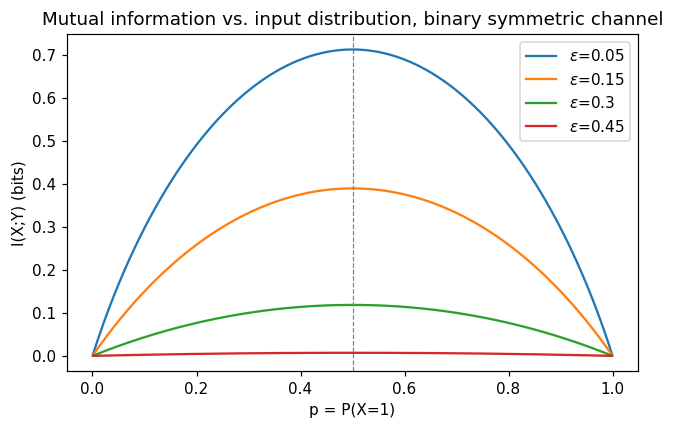

eps=0.05: argmax p = 0.498, max I = 0.7136, 1-H_b(eps) = 0.7136
eps=0.15: argmax p = 0.498, max I = 0.3902, 1-H_b(eps) = 0.3902
eps=0.30: argmax p = 0.502, max I = 0.1187, 1-H_b(eps) = 0.1187
eps=0.45: argmax p = 0.498, max I = 0.0072, 1-H_b(eps) = 0.0072


In [5]:
I_XY_func = sp.lambdify((p_sym, eps_sym), I_XY, "numpy")

p_vals = np.linspace(1e-3, 1 - 1e-3, 300)
fig, ax = plt.subplots(figsize=(6, 4))
for eps_val in [0.05, 0.15, 0.3, 0.45]:
    ax.plot(p_vals, I_XY_func(p_vals, eps_val), label=f"$\\varepsilon$={eps_val}")
ax.axvline(0.5, color="grey", ls="--", lw=0.8)
ax.set_xlabel("p = P(X=1)")
ax.set_ylabel("I(X;Y) (bits)")
ax.set_title("Mutual information vs. input distribution, binary symmetric channel")
ax.legend()
plt.tight_layout()
plt.savefig("figures/02_bsc_mutual_information.png")
plt.show()

# Verify the max over p (numerically, for each curve) lands at p=0.5 and matches 1 - H_b(eps)
for eps_val in [0.05, 0.15, 0.3, 0.45]:
    curve = I_XY_func(p_vals, eps_val)
    p_argmax = p_vals[np.argmax(curve)]
    capacity = 1 - (-eps_val * np.log2(eps_val) - (1 - eps_val) * np.log2(1 - eps_val))
    print(f"eps={eps_val:.2f}: argmax p = {p_argmax:.3f}, "
          f"max I = {curve.max():.4f}, 1-H_b(eps) = {capacity:.4f}")

## 2. Information / entropy maximization

**Question**: given some constraint on a distribution (e.g. it's over a fixed finite set of outcomes, or it has a fixed variance), which distribution has the *most* entropy? This matters for neural coding because of the **efficient coding hypothesis**: a neuron with a limited output range (e.g. a firing rate that saturates) transmits the most information about its input when its output distribution is as close to this maximum-entropy shape as possible.

### Discrete case: fixed number of outcomes → uniform

Maximize $H(p) = -\sum_i p_i \log_2 p_i$ subject to $\sum_i p_i = 1$ (Lagrange multiplier $\lambda$):
$$\mathcal{L} = -\sum_i p_i\log_2 p_i - \lambda\Big(\sum_i p_i - 1\Big)$$
$$\frac{\partial \mathcal{L}}{\partial p_i} = -\log_2 p_i - \frac{1}{\ln 2} - \lambda = 0 \implies p_i = \text{constant for all } i$$

Since every $p_i$ solves to the same constant, and they must sum to 1, $p_i = 1/n$: **the uniform distribution maximizes entropy over a fixed number of outcomes**. Verifying this symbolically for a small case, and numerically for many random distributions with the same support size, is a good check that this isn't a fluke of the algebra.

In [6]:
# Symbolic check for n=3: maximize H(p1,p2,1-p1-p2) over the 2 free parameters
p1, p2 = sp.symbols("p1 p2", positive=True)
p3 = 1 - p1 - p2
H3 = -(p1 * sp.log(p1, 2) + p2 * sp.log(p2, 2) + p3 * sp.log(p3, 2))

stationary = sp.solve([sp.diff(H3, p1), sp.diff(H3, p2)], [p1, p2])
print("Stationary point (p1, p2):", stationary)
print("=> p3 =", 1 - sum(stationary.values()))
print("All three equal 1/3, confirming the uniform distribution is the critical point.\n")

# Numerical check: sample many random distributions over n=6 outcomes,
# confirm none beats the uniform distribution's entropy
n = 6
n_samples = 20_000
random_dists = rng.dirichlet(np.ones(n), size=n_samples)
entropies = -np.sum(random_dists * np.log2(random_dists, where=random_dists > 0,
                                           out=np.zeros_like(random_dists)), axis=1)
uniform_entropy = np.log2(n)

print(f"Uniform distribution entropy (n={n}): {uniform_entropy:.4f} bits")
print(f"Max entropy among {n_samples} random distributions: {entropies.max():.4f} bits")
print(f"(should be <= uniform, approaching it only as a sampled distribution -> uniform)")

Stationary point (p1, p2): {p1: 1/3, p2: 1/3}
=> p3 = 1/3
All three equal 1/3, confirming the uniform distribution is the critical point.

Uniform distribution entropy (n=6): 2.5850 bits
Max entropy among 20000 random distributions: 2.5778 bits
(should be <= uniform, approaching it only as a sampled distribution -> uniform)


### Continuous case: fixed variance → Gaussian

For a continuous distribution, entropy is defined with an integral (differential entropy) $h(p) = -\int p(x)\log_2 p(x)\,dx$. Maximize this subject to two constraints — normalization ($\int p=1$) and fixed variance ($\int x^2 p(x)\,dx = \sigma^2$, taking the mean as 0 WLOG) — using two Lagrange multipliers $\lambda_0,\lambda_1$:

$$\mathcal{L}[p] = -\int p\log_2 p\,dx - \lambda_0\Big(\int p\,dx - 1\Big) - \lambda_1\Big(\int x^2 p\,dx - \sigma^2\Big)$$

Taking the functional derivative $\delta\mathcal{L}/\delta p(x) = 0$ (calculus of variations — treat $p(x)$ at each point as a free variable):

$$-\frac{1}{\ln 2}(1 + \ln p(x)) - \lambda_0 - \lambda_1 x^2 = 0 \implies p(x) = \exp\big(-1 - \lambda_0\ln 2 - \lambda_1 x^2 \ln 2\big)$$

This is a Gaussian shape ($p(x) \propto e^{-c x^2}$); solving the two Lagrange multipliers against the two constraints (normalize to 1, match variance $\sigma^2$) pins it down to exactly $\mathcal{N}(0,\sigma^2)$. **The Gaussian is the maximum-entropy distribution for a fixed variance** — of all distributions with a given "spread," the Gaussian is the least committal / most uncertain.

Known closed forms for differential entropy at fixed variance $\sigma^2$ (useful for a numeric sanity check, since these have been worked out in closed form for standard distributions):

- Gaussian: $h = \tfrac{1}{2}\log_2(2\pi e\,\sigma^2)$
- Uniform on $[-a,a]$ (variance $\sigma^2=a^2/3$): $h = \log_2(2a) = \log_2\!\big(2\sqrt{3\sigma^2}\big)$
- Laplace, scale $b$ (variance $\sigma^2=2b^2$): $h = \log_2(2eb)$

If the derivation above is right, the Gaussian value should be the largest of the three for the same $\sigma^2$.

In [7]:
sigma2 = 2.0  # fixed variance, arbitrary units

h_gaussian = 0.5 * np.log2(2 * np.pi * np.e * sigma2)
h_uniform = np.log2(2 * np.sqrt(3 * sigma2))
b = np.sqrt(sigma2 / 2)
h_laplace = np.log2(2 * np.e * b)

print(f"sigma^2 = {sigma2}")
print(f"Gaussian differential entropy: {h_gaussian:.4f} bits")
print(f"Uniform differential entropy:  {h_uniform:.4f} bits")
print(f"Laplace differential entropy:  {h_laplace:.4f} bits")
print(f"\nGaussian is largest: {h_gaussian > h_uniform and h_gaussian > h_laplace}")

# Cross-check with a numerical (histogram-based) entropy estimate from samples,
# independent of the closed-form formulas above
def sample_entropy_bits(samples, n_bins=200):
    counts, edges = np.histogram(samples, bins=n_bins, density=True)
    bin_width = edges[1] - edges[0]
    p = counts * bin_width
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p / bin_width)))  # differential entropy estimate


n_samp = 2_000_000
gauss_samples = rng.normal(0, np.sqrt(sigma2), n_samp)
a = np.sqrt(3 * sigma2)
unif_samples = rng.uniform(-a, a, n_samp)
laplace_samples = rng.laplace(0, b, n_samp)

print("\nHistogram-based estimates (should roughly match the closed forms above):")
print(f"Gaussian: {sample_entropy_bits(gauss_samples):.4f} bits")
print(f"Uniform:  {sample_entropy_bits(unif_samples):.4f} bits")
print(f"Laplace:  {sample_entropy_bits(laplace_samples):.4f} bits")

sigma^2 = 2.0
Gaussian differential entropy: 2.5471 bits
Uniform differential entropy:  2.2925 bits
Laplace differential entropy:  2.4427 bits

Gaussian is largest: True



Histogram-based estimates (should roughly match the closed forms above):
Gaussian: 2.5469 bits
Uniform:  2.2924 bits
Laplace:  2.4437 bits


### Why this matters: Laughlin's efficient coding result

A neuron with a firing rate confined to some fixed range $[0, r_\max]$ is like the discrete case above but over a continuum of outputs bounded to an interval — the maximum-entropy output distribution there is **uniform over $[0, r_\max]$**, not Gaussian (a bounded-support constraint, not a fixed-variance one).

Laughlin (1981) measured the fly large monopolar cell (LMC)'s response to contrast and found its **contrast-response curve is shaped almost exactly like the cumulative distribution function (CDF) of the contrast values the fly actually encounters in natural scenes** — i.e. the neuron's input/output mapping performs *histogram equalization*: whatever contrast value comes in, the output firing rate distribution comes out uniform. That's precisely the max-entropy discrete/bounded-range result above, found in a real biological measurement rather than derived — the fly's photoreceptor is (very nearly) using its limited dynamic range optimally, in the information-theoretic sense proven above.

Quick illustration of what histogram equalization actually does: given some skewed input distribution, transforming through its own CDF produces a uniform output.

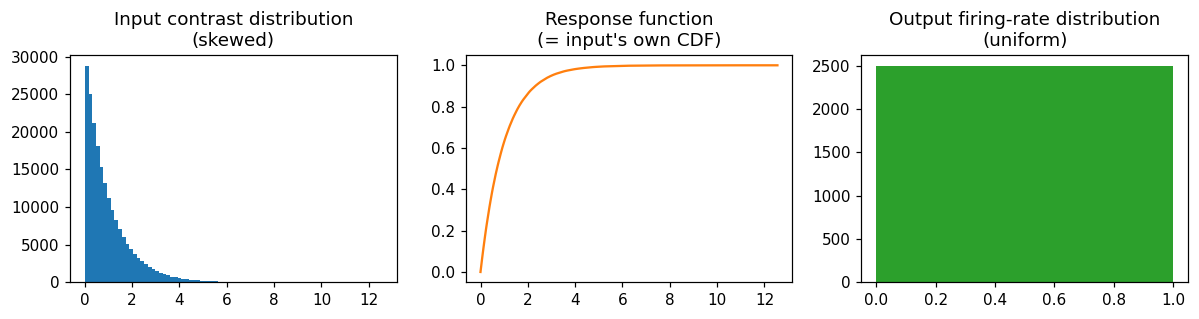

Output entropy (bits, 80 bins): 6.3219
Max possible for 80 uniform bins: 6.3219 bits


In [8]:
from scipy.stats import expon

# A skewed "natural contrast" distribution as a stand-in (exponential-like skew,
# not a real dataset -- illustrates the mechanism, not a replication of Laughlin's data)
contrast_samples = expon.rvs(scale=1.0, size=200_000, random_state=rng)

# Empirical CDF used as the "neuron's response function"
sorted_samples = np.sort(contrast_samples)
ecdf_vals = np.arange(1, len(sorted_samples) + 1) / len(sorted_samples)


def response_function(x):
    return np.interp(x, sorted_samples, ecdf_vals)


output_rates = response_function(contrast_samples)

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
axes[0].hist(contrast_samples, bins=80, color="C0")
axes[0].set_title("Input contrast distribution\n(skewed)")
axes[1].plot(sorted_samples, ecdf_vals, color="C1")
axes[1].set_title("Response function\n(= input's own CDF)")
axes[2].hist(output_rates, bins=80, color="C2")
axes[2].set_title("Output firing-rate distribution\n(uniform)")
plt.tight_layout()
plt.savefig("figures/03_histogram_equalization.png")
plt.show()

print(f"Output entropy (bits, 80 bins): {entropy_bits(np.histogram(output_rates, bins=80)[0] / len(output_rates)):.4f}")
print(f"Max possible for 80 uniform bins: {np.log2(80):.4f} bits")

## 3. Entropy and information for spike trains — the direct method

Following Strong et al. (1998): discretize a spike train into time bins of width $\Delta t$, small enough that each bin holds at most one spike. Over a window of $T$ bins, the spike train becomes a binary **word** of length $T$ (e.g. `0110100...`) — one of $2^T$ possible words.

Repeat the same stimulus many times (trials) and record the resulting word in each trial. Two entropies matter:

- **Total entropy** $H_{\text{total}}$: entropy of the word distribution pooled across *all* trials and *all* times — how variable the response is overall.
- **Noise entropy** $H_{\text{noise}}$: entropy of the word distribution *at a single, fixed moment in the stimulus*, across repeated trials — how variable the response is when the stimulus is held fixed, i.e. variability that has nothing to do with the stimulus.

$$I_{\text{stim}} = H_{\text{total}} - \langle H_{\text{noise}}\rangle_{\text{time}}$$

This is exactly the $I(X;Y) = H(Y) - H(Y\mid X)$ decomposition from Section 1, with $Y$ = the spike word and $X$ = time-in-stimulus (a stand-in for "which stimulus condition"). Whatever entropy is left after subtracting out the trial-to-trial noise is the part of the response that's actually informative about the stimulus.

**A caveat worth stating rather than skipping**: the naive plug-in entropy estimate (just computing $-\sum \hat p \log_2 \hat p$ from empirical word counts) is *biased upward* when the number of trials is small relative to $2^T$ possible words — many words are never observed, which looks like less entropy than the true distribution has. Panzeri & Treves (1996) derived a bias-correction term; it's not implemented here (would need many more trials than this toy example uses to matter), but it's the reason real spike-train information estimates in the literature always report a bias correction or an extrapolation over data size, not just the raw plug-in number.

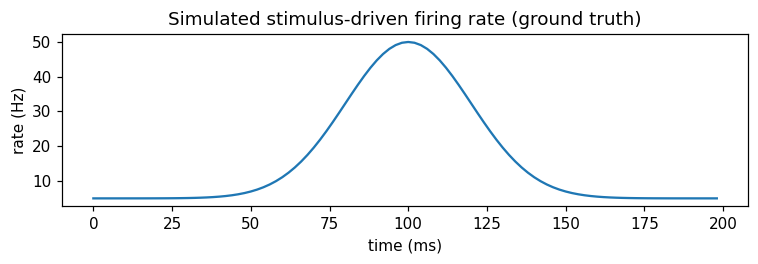

In [9]:
# Simulate: a neuron with a stimulus-driven rate bump on top of a baseline,
# repeated over many trials with independent Poisson noise each trial.
dt_ms = 2.0
duration_ms = 200.0
time_bins = np.arange(0, duration_ms, dt_ms)
n_time_bins = len(time_bins)
n_trials = 3000

baseline_hz = 5.0
peak_hz = 45.0
bump_center_ms, bump_sigma_ms = 100.0, 20.0
rate_hz = baseline_hz + peak_hz * np.exp(-0.5 * ((time_bins - bump_center_ms) / bump_sigma_ms) ** 2)
p_spike = rate_hz * dt_ms / 1000.0  # spike probability per bin (small, so <=1 spike/bin is realistic)

spikes = rng.random((n_trials, n_time_bins)) < p_spike[None, :]  # shape (trials, time_bins)

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.plot(time_bins, rate_hz)
ax.set_xlabel("time (ms)")
ax.set_ylabel("rate (Hz)")
ax.set_title("Simulated stimulus-driven firing rate (ground truth)")
plt.tight_layout()
plt.savefig("figures/04_rate_profile.png")
plt.show()

In [10]:
def word_entropy_bits(binary_words):
    """binary_words: (n_samples, T) boolean array. Returns plug-in entropy in bits
    of the empirical word distribution (each row -> one T-bit word)."""
    T = binary_words.shape[1]
    powers = 1 << np.arange(T)
    word_ids = binary_words.astype(int) @ powers  # integer id per word, 0..2^T-1
    counts = np.bincount(word_ids, minlength=2 ** T)
    p = counts / counts.sum()
    return entropy_bits(p)


def direct_method_info(spikes, T):
    """spikes: (n_trials, n_time_bins) boolean. Groups time into non-overlapping
    windows of T bins (each window = one 'letter' position), computes total
    entropy (pooled across trials+windows) and mean noise entropy (across
    trials, per window), returns (info_bits, total_entropy, mean_noise_entropy)."""
    n_trials, n_time_bins = spikes.shape
    n_windows = n_time_bins // T
    trimmed = spikes[:, : n_windows * T].reshape(n_trials, n_windows, T)

    all_words = trimmed.reshape(-1, T)
    H_total = word_entropy_bits(all_words)

    noise_entropies = [word_entropy_bits(trimmed[:, w, :]) for w in range(n_windows)]
    H_noise = float(np.mean(noise_entropies))

    return H_total - H_noise, H_total, H_noise


info, H_total, H_noise = direct_method_info(spikes, T=4)
print(f"H_total  = {H_total:.4f} bits/word")
print(f"H_noise  = {H_noise:.4f} bits/word (avg over time windows)")
print(f"I_stim   = {info:.4f} bits/word")
print(f"(sanity: I_stim should be positive and well below the word's own {4} bits of raw capacity)")

H_total  = 0.8241 bits/word
H_noise  = 0.7486 bits/word (avg over time windows)
I_stim   = 0.0755 bits/word
(sanity: I_stim should be positive and well below the word's own 4 bits of raw capacity)


### Seeing the small-sample bias directly

Repeat the estimate for increasing word length $T$, holding the number of trials fixed. As $T$ grows, $2^T$ possible words quickly outgrows the number of trials, so many words are never observed and the *noise* entropy estimate collapses toward 0 artificially fast (each trial's window looks "perfectly reproducible" simply because there isn't enough data to see the variability that's actually there) — which makes $I_{\text{stim}} = H_{\text{total}} - H_{\text{noise}}$ **overestimate** the true information. This is the bias mentioned above, made visible rather than just asserted.

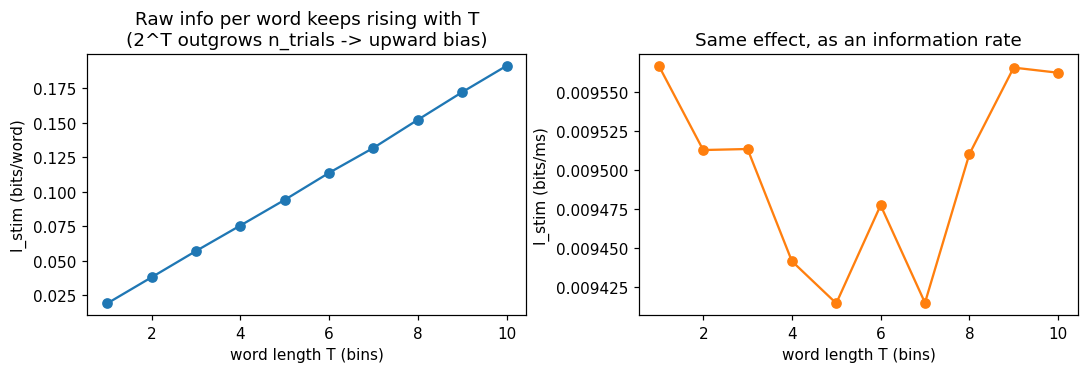

n_trials = 3000, so words become undersampled once 2^T approaches that: 2^10 = 1024 vs n_trials = 3000


In [11]:
T_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = [direct_method_info(spikes, T) for T in T_values]
info_bits_per_word = np.array([r[0] for r in results])
info_bits_per_ms = info_bits_per_word / (np.array(T_values) * dt_ms)  # normalize to a rate

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(T_values, info_bits_per_word, marker="o")
axes[0].set_xlabel("word length T (bins)")
axes[0].set_ylabel("I_stim (bits/word)")
axes[0].set_title("Raw info per word keeps rising with T\n(2^T outgrows n_trials -> upward bias)")

axes[1].plot(T_values, info_bits_per_ms, marker="o", color="C1")
axes[1].set_xlabel("word length T (bins)")
axes[1].set_ylabel("I_stim (bits/ms)")
axes[1].set_title("Same effect, as an information rate")

plt.tight_layout()
plt.savefig("figures/05_bias_vs_word_length.png")
plt.show()

print(f"n_trials = {n_trials}, so words become undersampled once 2^T approaches that: "
      f"2^10 = {2**10} vs n_trials = {n_trials}")

## 4. Bonus: deriving BCI information transfer rate (ITR) from the same machinery

[03-bci-signal-processing's README](../../../03-bci-signal-processing/README.md) names ITR (bits/min) as a shared decoder metric. It's not a separate ad-hoc formula — it's mutual information for a specific, simple channel model: an $N$-class decoder (e.g. $N$ possible letters/commands) whose confusion matrix is **symmetric** — correct with probability $P$, and every wrong class equally likely with probability $(1-P)/(N-1)$ each.

This is a direct generalization of the binary symmetric channel from Section 1 (that was $N=2$). For $X$ = intended class (assume uniform over $N$, i.e. the user picks any target equally often) and $Y$ = decoded class:

$$H(Y\mid X) = -P\log_2 P - (1-P)\log_2\frac{1-P}{N-1} \qquad \text{(same shape as } H_b(\varepsilon) \text{ above, just } N\text{-ary)}$$

Because the confusion matrix is symmetric, $Y$'s marginal distribution is also uniform over $N$ classes (same argument as the BSC hitting its capacity at $p=1/2$), so $H(Y) = \log_2 N$, giving the per-trial information

$$B = I(X;Y) = H(Y) - H(Y\mid X) = \log_2 N + P\log_2 P + (1-P)\log_2\frac{1-P}{N-1} \quad \text{bits/trial}.$$

This is exactly Wolpaw et al.'s BCI bits-per-trial formula — derived here from the same $I=H(Y)-H(Y\mid X)$ identity proved in Section 1, not a new definition. Convert to a rate with the time per trial: $\text{ITR (bits/min)} = B \times \frac{60}{t_{\text{trial}}(\text{s})}$.

In [12]:
def itr_bits_per_trial(N, P):
    """Wolpaw ITR formula, derived above, for an N-class symmetric-confusion decoder
    with per-trial accuracy P."""
    if P <= 0:
        return -np.inf
    if P >= 1:
        return np.log2(N)
    return np.log2(N) + P * np.log2(P) + (1 - P) * np.log2((1 - P) / (N - 1))


# Example: a P300 speller (03-D) with a 6x6 matrix (N=36 symbols), 2.5s/trial,
# at a few plausible accuracies -- illustrative numbers, not a real dataset
N = 36
t_trial_s = 2.5
for P in [0.7, 0.8, 0.9, 0.95, 0.99]:
    B = itr_bits_per_trial(N, P)
    itr_bits_per_min = B * 60 / t_trial_s
    print(f"P={P:.2f}: B={B:.3f} bits/trial, ITR={itr_bits_per_min:.2f} bits/min")

# Sanity checks against known limits
print(f"\nP=1/N (chance) -> B = {itr_bits_per_trial(N, 1/N):.4f} bits/trial (should be ~0)")
print(f"P=1 (perfect)   -> B = {itr_bits_per_trial(N, 1.0):.4f} bits/trial (should be log2(N) = {np.log2(N):.4f})")

P=0.70: B=2.750 bits/trial, ITR=66.00 bits/min
P=0.80: B=3.422 bits/trial, ITR=82.13 bits/min
P=0.90: B=4.188 bits/trial, ITR=100.51 bits/min
P=0.95: B=4.627 bits/trial, ITR=111.05 bits/min
P=0.99: B=5.038 bits/trial, ITR=120.91 bits/min

P=1/N (chance) -> B = 0.0000 bits/trial (should be ~0)
P=1 (perfect)   -> B = 5.1699 bits/trial (should be log2(N) = 5.1699)
